# Feature Engineering & Analysis: Small-Donor Funding in the House

Builds the `user_full` analysis dataframe from multiple public sources,
screens candidate features, and runs the full regression, mediation, and
difference-in-differences analyses.

**Pipeline:**
1. Config & imports
2. Load base data
3. Feature building (DW-NOMINATE, margins, seniority, gender, tweet features)
4. Build `user_full` analysis dataframe
5. Feature screening
6. Final model + VIF diagnostics
7. Coefficient plot
8. Mediation analysis (outrage → retweets → donations)
9. Caucus membership + Squad
10. [EXPLORED — NOT RETAINED] Follower count & engagement rate
11. Historical FEC: F-test progressive model comparison
12. Cycle-to-cycle predictability
13. Difference-in-differences analysis
14. DiD robustness checks
15. Cross-validation
16. Key findings summary

**Final model:**
```
pct_small_donors ~ log_avg_retweets + terms_served + avg_fear + is_female + competitive + is_squad
R² = 0.412, Adj R² = 0.402, N = 361
```

---
## 1 · Config & Imports

In [2]:
import pandas as pd
import numpy as np
import json
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from scipy.stats import zscore, linregress, entropy, f as f_dist
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 100)

# ── File paths ────────────────────────────────────────────────────────
SAMPLE_CSV       = "../data/processed/sample_house_full.csv"
OUTPUT_CSV       = "../data/processed/house_with_features.csv"
ENRICHED_TWEETS  = "../data/processed/house_tweets_enriched.csv"
LEGISLATORS_JSON = "../data/raw/legislators/legislators-current.json"
HOUSE_RETURNS    = "../data/raw/fec/1976-2024-house.tab"
USER_SUMMARY_CSV = "../data/processed/user_partisanship_summary.csv"
CAUCUS_CSV       = "../data/processed/caucus_memberships.csv"
FOLLOWERS_CSV    = "../data/processed/follower_counts.csv"

VOTEVIEW_URL  = "https://voteview.com/static/data/out/members/HSall_members.csv"
CONGRESS_NUM  = 118

---
## 2 · Load Base Data

In [3]:
sample = pd.read_csv(SAMPLE_CSV)
sample["handle_lower"] = sample["twitter"].str.lower().str.strip()
print(f"Sample members: {len(sample)}")

tweets = pd.read_csv(ENRICHED_TWEETS, low_memory=False)
tweets["handle_lower"] = tweets["Account"].str.lower().str.strip()
tweets["Created At"] = pd.to_datetime(tweets["Created At"], errors="coerce", utc=True)
print(f"Tweets: {len(tweets):,}")

vv = pd.read_csv(VOTEVIEW_URL)
vv118 = vv[vv["congress"] == CONGRESS_NUM].copy()
vv118_house = vv118[vv118["chamber"] == "House"]
print(f"VoteView 118th House: {len(vv118_house)}")

user = pd.read_csv(USER_SUMMARY_CSV)
print(f"User summary: {len(user)} members")

Sample members: 425
Tweets: 438,674
VoteView 118th House: 451
User summary: 403 members


---
## 3 · Feature Building

Merges external features onto `sample_house_full.csv` and saves to `house_with_features.csv`.
Skips Census ACS district demographics — tested but none were significant predictors.

### 3a · DW-NOMINATE (voting ideology)

In [4]:
vv_cols = vv118_house[["bioguide_id", "nominate_dim1", "nominate_dim2",
                        "nokken_poole_dim1", "nokken_poole_dim2",
                        "nominate_number_of_votes"]].copy()
vv_cols = vv_cols.rename(columns={"bioguide_id": "bioguide"}).drop_duplicates("bioguide")

sample = sample.merge(vv_cols, on="bioguide", how="left")
sample["nominate_abs"] = sample["nominate_dim1"].abs()

print(f"DW-NOMINATE coverage: {sample['nominate_dim1'].notna().sum()} / {len(sample)}")
print(f"\nCorrelations with pct_small_donors:")
print(f"  nominate_dim1:  r = {sample['pct_small_donors'].corr(sample['nominate_dim1']):+.3f}")
print(f"  |nominate_dim1|: r = {sample['pct_small_donors'].corr(sample['nominate_abs']):+.3f}")

DW-NOMINATE coverage: 422 / 425

Correlations with pct_small_donors:
  nominate_dim1:  r = +0.125
  |nominate_dim1|: r = +0.179


### 3b · Election competitiveness (margin of victory)

In [5]:
# ── Load MIT Election Lab House returns ────────────────────────────────
house = pd.read_csv(HOUSE_RETURNS, sep=",")
h24 = house[(house["year"] == 2024) & (house["stage"] == "GEN")].copy()
print(f"2024 general election rows: {len(h24)}")

# ── Compute margin of victory per district ────────────────────────────
district_totals = h24.groupby(["state_po", "district"])["candidatevotes"].sum().reset_index()
district_totals = district_totals.rename(columns={"candidatevotes": "total_votes"})
h24 = h24.merge(district_totals, on=["state_po", "district"])
h24["vote_share"] = h24["candidatevotes"] / h24["total_votes"] * 100

margins = []
for (state, dist), grp in h24.groupby(["state_po", "district"]):
    top2 = grp.nlargest(2, "candidatevotes")
    winner = top2.iloc[0]
    runner_up_share = top2.iloc[1]["vote_share"] if len(top2) > 1 else 0
    margins.append({
        "state": state, "district": int(dist) if dist != 0 else 0,
        "margin_of_victory": winner["vote_share"] - runner_up_share,
        "winner_share": winner["vote_share"], "total_votes": winner["total_votes"],
    })

margins_df = pd.DataFrame(margins)
margins_df["competitive"] = (margins_df["margin_of_victory"] < 10).astype(int)
print(f"Districts: {len(margins_df)}")
print(f"Competitive (<10pt): {margins_df['competitive'].sum()}")

2024 general election rows: 1353


/var/folders/st/yx5_mdvj4bdbm59sg4_7n26m0000gq/T/ipykernel_44946/450583848.py:2: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  house = pd.read_csv(HOUSE_RETURNS, sep=",")


Districts: 436
Competitive (<10pt): 70


In [6]:
# ── Get district codes from VoteView and merge margins ────────────────
vv_districts = vv118_house[["bioguide_id", "state_abbrev", "district_code"]].rename(
    columns={"bioguide_id": "bioguide"})
sample = sample.merge(vv_districts, on="bioguide", how="left", suffixes=("", "_vv"))
if "state_abbrev_vv" in sample.columns:
    sample["state_abbrev"] = sample["state_abbrev"].fillna(sample["state_abbrev_vv"])
    sample["district_code"] = sample["district_code"].fillna(sample["district_code_vv"])
    sample = sample.drop(columns=[c for c in sample.columns if c.endswith("_vv")])

sample["join_state"] = sample["state_abbrev"]
sample["join_district"] = sample["district_code"].fillna(0).astype(int)
margins_df["join_state"] = margins_df["state"]
margins_df["join_district"] = margins_df["district"].astype(int)

sample = sample.merge(
    margins_df[["join_state", "join_district", "margin_of_victory", "competitive", "winner_share", "total_votes"]],
    on=["join_state", "join_district"], how="left")
sample = sample.drop(columns=["join_state", "join_district"], errors="ignore")

print(f"Margin matched: {sample['margin_of_victory'].notna().sum()} / {len(sample)}")

Margin matched: 415 / 425


### 3c · Member features: seniority, gender, age

In [7]:
# ── Seniority ─────────────────────────────────────────────────────────
with open(LEGISLATORS_JSON) as f:
    legislators = json.load(f)

seniority = {}
for m in legislators:
    bid = m["id"].get("bioguide", "")
    terms = m.get("terms", [])
    house_terms = [t for t in terms if t.get("type") == "rep"]
    seniority[bid] = len(house_terms)

sample["terms_served"] = sample["bioguide"].map(seniority)
print(f"Seniority coverage: {sample['terms_served'].notna().sum()}")
print(f"Range: {sample['terms_served'].min():.0f} – {sample['terms_served'].max():.0f}")

# ── Gender ────────────────────────────────────────────────────────────
gender_map = {}
for m in legislators:
    bid = m["id"].get("bioguide", "")
    gender_map[bid] = m.get("bio", {}).get("gender", "")

sample["is_female"] = sample["bioguide"].map(gender_map).apply(lambda x: 1 if x == "F" else 0)
print(f"Female members: {sample['is_female'].sum()}")

# ── Age ────────────────────────────────────────────────────────────────
vv_age = vv118_house[["bioguide_id", "born"]].rename(columns={"bioguide_id": "bioguide"})
vv_age["age_in_2024"] = 2024 - vv_age["born"]
sample = sample.merge(vv_age[["bioguide", "age_in_2024"]], on="bioguide", how="left")
print(f"Age coverage: {sample['age_in_2024'].notna().sum()}")

Seniority coverage: 375
Range: 1 – 23
Female members: 104
Age coverage: 422


### 3d · Save enriched sample

In [8]:
sample.to_csv(OUTPUT_CSV, index=False)
print(f"Saved → {OUTPUT_CSV}  ({len(sample)} rows, {len(sample.columns)} columns)")
print(f"Columns: {sample.columns.tolist()}")

Saved → ../data/processed/house_with_features.csv  (425 rows, 39 columns)
Columns: ['Name', 'Total Raised', 'Total from Small Donors', 'Percent from Small Donors*', 'total money raised', 'party_code', 'party_full', 'Total Raised_num', 'Total from Small Donors_num', 'pct_small_donors', 'clean_name', 'match_score', 'match_method', 'first', 'last', 'official_full', 'party', 'chamber', 'state', 'bioguide', 'twitter', 'quartile', 'sample_method', 'handle_lower', 'nominate_dim1', 'nominate_dim2', 'nokken_poole_dim1', 'nokken_poole_dim2', 'nominate_number_of_votes', 'nominate_abs', 'state_abbrev', 'district_code', 'margin_of_victory', 'competitive', 'winner_share', 'total_votes', 'terms_served', 'is_female', 'age_in_2024']


### 3e · Tweet-derived features

Sentiment slope, emotion entropy, dominant emotion, text/behavior features.
All computed from `house_tweets_enriched.csv`.

In [9]:
# ── Sentiment slope (negativity trend over time) ────────────────────────
ref_date = tweets["Created At"].min()
tweets["days_since_start"] = (tweets["Created At"] - ref_date).dt.total_seconds() / 86400

def calc_slopes(df):
    results = {}
    for handle, grp in df.groupby("handle_lower"):
        g = grp.dropna(subset=["days_since_start", "sentiment_score"])
        if len(g) < 10:
            results[handle] = np.nan
        else:
            slope, _, _, _, _ = linregress(g["days_since_start"].values, g["sentiment_score"].values)
            results[handle] = slope
    return results

slopes = calc_slopes(tweets)
sentiment_trends = pd.DataFrame(list(slopes.items()), columns=["handle_lower", "sentiment_slope"])
print(f"Sentiment slopes: {len(sentiment_trends)}")
print(f"Getting angrier: {(sentiment_trends['sentiment_slope'] < 0).sum()}")
print(f"Getting nicer:   {(sentiment_trends['sentiment_slope'] > 0).sum()}")

Sentiment slopes: 411
Getting angrier: 154
Getting nicer:   254


In [10]:
# ── Emotion entropy + dominant emotion ────────────────────────────────
emotions = ["anger", "fear", "joy", "disgust", "sadness", "surprise", "neutral"]

def emotion_entropy(row):
    scores = [row[e] for e in emotions]
    total = sum(scores)
    if total == 0: return np.nan
    probs = [s / total for s in scores]
    return entropy(probs)

tweets["emotion_entropy"] = tweets.apply(emotion_entropy, axis=1)
tweets["dominant_emotion"] = tweets[emotions].idxmax(axis=1)

emotion_features = tweets.groupby("handle_lower").agg(
    avg_emotion_entropy  = ("emotion_entropy", "mean"),
    pct_anger_dominant   = ("dominant_emotion", lambda x: (x == "anger").mean()),
    pct_joy_dominant     = ("dominant_emotion", lambda x: (x == "joy").mean()),
    pct_disgust_dominant = ("dominant_emotion", lambda x: (x == "disgust").mean()),
    pct_fear_dominant    = ("dominant_emotion", lambda x: (x == "fear").mean()),
    pct_neutral_dominant = ("dominant_emotion", lambda x: (x == "neutral").mean()),
).reset_index()

# ── Extreme negative / neutral shares ────────────────────────────────
extreme_features = tweets.groupby("handle_lower").agg(
    pct_extreme_neg = ("sentiment_score", lambda x: (x < -0.8).mean()),
    pct_extreme_pos = ("sentiment_score", lambda x: (x > 0.8).mean()),
    pct_neutral     = ("label", lambda x: (x == "neutral").mean()),
).reset_index()

print(f"Emotion features: {len(emotion_features)} members")
print(f"Extreme features: {len(extreme_features)} members")

Emotion features: 411 members
Extreme features: 411 members


In [11]:
# ── Text/behavior features ────────────────────────────────────────────
import re

tweets["n_hashtags"]      = tweets["Text"].str.count(r"#\w+")
tweets["n_mentions"]      = tweets["Text"].str.count(r"@\w+")
tweets["is_reply"]        = tweets["Text"].str.strip().str.startswith("@").astype(int)
tweets["has_link"]        = tweets["Text"].str.contains(r"https?://t\.co/", na=False).astype(int)
tweets["word_count"]      = tweets["clean_text"].str.split().str.len()
tweets["has_exclamation"] = tweets["Text"].str.contains("!", na=False).astype(int)
tweets["has_question"]    = tweets["Text"].str.contains(r"\?", na=False).astype(int)
tweets["n_caps_words"]    = tweets["Text"].apply(
    lambda x: len([w for w in str(x).split() if w.isupper() and len(w) >= 3]))
tweets["hour"]            = tweets["Created At"].dt.hour
tweets["is_off_hours"]    = ((tweets["hour"] < 7) | (tweets["hour"] > 22)).astype(int)
tweets["is_weekend"]      = (tweets["Created At"].dt.dayofweek >= 5).astype(int)

text_features = tweets.groupby("handle_lower").agg(
    avg_hashtags       = ("n_hashtags", "mean"),
    pct_with_hashtags  = ("n_hashtags", lambda x: (x > 0).mean()),
    avg_mentions       = ("n_mentions", "mean"),
    pct_replies        = ("is_reply", "mean"),
    pct_with_links     = ("has_link", "mean"),
    avg_word_count     = ("word_count", "mean"),
    pct_exclamation    = ("has_exclamation", "mean"),
    pct_question       = ("has_question", "mean"),
    avg_caps_words     = ("n_caps_words", "mean"),
    pct_off_hours      = ("is_off_hours", "mean"),
    pct_weekend        = ("is_weekend", "mean"),
    avg_retweets_raw   = ("Retweets", "mean"),
    avg_likes_raw      = ("Likes", "mean"),
).reset_index()

text_features["rt_like_ratio"] = text_features["avg_retweets_raw"] / text_features["avg_likes_raw"].clip(lower=1)
text_features["engagement_per_word"] = (
    (text_features["avg_retweets_raw"] + text_features["avg_likes_raw"]) / text_features["avg_word_count"].clip(lower=1))
text_features["log_engagement_per_word"] = np.log1p(text_features["engagement_per_word"])

print(f"Text features: {len(text_features)} members")

Text features: 411 members


---
## 4 · Build Analysis Dataframe

Merges all feature sources into `user_full` — one row per member.
**Always run from scratch to avoid duplicate row issues.**

In [14]:
# ── Load and merge historical FEC data ───────────────────────────────
# NOTE: Run after user_full is built above
import os

fec_files = {
    2022: "../data/raw/fec/small_donors_2022.csv",
    2020: "../data/raw/fec/small_donors_2020.csv",
    2018: "../data/raw/fec/small_donors_2018.csv",
    2016: "../data/raw/fec/small_donors_2016.csv",
    2014: "../data/raw/fec/small_donors_2014.csv",
    2012: "../data/raw/fec/small_donors_2012.csv",
    2010: "../data/raw/fec/small_donors_2010.csv",
    2008: "../data/raw/fec/small_donors_2008.csv",
}

def parse_fec_csv(path, year):
    df = pd.read_csv(path)
    df = df.rename(columns={"Name": "raw_name"})
    pct_col = [c for c in df.columns if "Percent" in c or "percent" in c]
    if pct_col:
        df["pct"] = (df[pct_col[0]].astype(str)
                     .str.replace("%", "", regex=False)
                     .pipe(pd.to_numeric, errors="coerce"))
    df["year"] = year
    df["raw_name"] = df["raw_name"].str.strip()
    return df[["raw_name", "pct", "year"]].dropna(subset=["pct"])

all_years = []
for year, path in fec_files.items():
    if os.path.exists(path):
        df = parse_fec_csv(path, year)
        all_years.append(df)
    else:
        print(f"⚠️ Missing: {path}")

historical = pd.concat(all_years, ignore_index=True)

# Match to bioguides via 2024 matched file
matched_2024 = pd.read_csv("../data/processed/fec_legislators_matched.csv")
name_to_bioguide = (matched_2024[["Name", "bioguide"]]
                    .dropna()
                    .drop_duplicates("Name")
                    .rename(columns={"Name": "raw_name"}))
historical = historical.merge(name_to_bioguide, on="raw_name", how="left")

# Pivot to wide
historical_wide = historical.pivot_table(
    index="bioguide", columns="year", values="pct", aggfunc="first").reset_index()
historical_wide.columns = ["bioguide"] + [f"pct_small_{y}" for y in historical_wide.columns[1:]]

# Drop existing historical columns to avoid conflicts on re-run
existing_hist_cols = [c for c in user_full.columns if c.startswith("pct_small_2") and c != "pct_small_donors"]
user_full = user_full.drop(columns=existing_hist_cols + ["pct_lag1", "pct_change_22_24",
             "pct_historical_avg", "n_cycles"], errors="ignore")

# Merge into user_full via sample bridge
sample_bio = sample[["handle_lower", "bioguide"]].dropna().drop_duplicates("handle_lower")
historical_wide = historical_wide.merge(sample_bio, on="bioguide", how="inner")
user_full = user_full.merge(
    historical_wide.drop(columns=["bioguide"]),
    on="handle_lower", how="left", suffixes=("", "_dup"))
user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]
user_full = user_full.drop_duplicates(subset="handle_lower")

# Create lag features
if "pct_small_2022" in user_full.columns:
    user_full["pct_lag1"] = user_full["pct_small_2022"]
    user_full["pct_change_22_24"] = user_full["pct_small_donors"] - user_full["pct_small_2022"]

lag_cols = [c for c in user_full.columns if c.startswith("pct_small_2") and c != "pct_small_donors"]
user_full["pct_historical_avg"] = user_full[lag_cols].mean(axis=1)
user_full["n_cycles"] = user_full[lag_cols].notna().sum(axis=1)

print(f"user_full rows: {len(user_full)}, unique: {user_full['handle_lower'].nunique()}")
print(f"Historical columns: {lag_cols}")
print(f"pct_lag1 coverage: {user_full['pct_lag1'].notna().sum()} / {len(user_full)}")

NameError: name 'user_full' is not defined

---
## 5 · Feature Screening

Tests each candidate feature individually against the base model
(`log_avg_retweets + terms_served`). Features selected for the final model:
- `avg_fear` (p = 0.005, ΔR² = +0.014)
- `is_female` (p = 0.005, ΔR² = +0.014)
- `competitive` (p = 0.009, ΔR² = +0.012)
- `is_squad` (p = 0.035, ΔR² = +0.007)

Dropped due to multicollinearity (VIF > 10): `avg_sentiment`, `outrage_index`,
`log_avg_likes`, `nominate_abs`, `log_tweet_count`.

In [ ]:
# ── Screen all features one at a time against base model ──────────────
base = "pct_small_donors ~ log_avg_retweets + terms_served"
analysis = user_full.dropna(subset=["terms_served"])
base_m = smf.ols(base, data=analysis).fit()

candidates = {
    "is_R": "Republican", "is_female": "Female", "age_in_2024": "Age",
    "nominate_dim1": "DW-NOMINATE (raw)", "nominate_abs": "|DW-NOMINATE|",
    "margin_of_victory": "Margin of Victory", "competitive": "Competitive District",
    "sentiment_slope": "Negativity Trend", "outrage_index": "Outrage Index",
    "avg_sentiment": "Avg Sentiment", "pct_negative": "% Negative Tweets",
    "avg_anger": "Avg Anger", "avg_disgust": "Avg Disgust",
    "avg_joy": "Avg Joy", "avg_fear": "Avg Fear",
    "log_tweet_count": "Tweet Volume", "log_avg_likes": "Avg Likes",
    "avg_emotion_entropy": "Emotion Diversity",
    "pct_anger_dominant": "% Anger-Dominant", "pct_neutral_dominant": "% Neutral-Dominant",
    "pct_extreme_neg": "% Extreme Negative",
    "pct_with_links": "% Tweets with Links", "avg_caps_words": "Avg ALL CAPS Words",
    "pct_replies": "% Reply Tweets", "avg_word_count": "Avg Word Count",
    "rt_like_ratio": "RT-to-Like Ratio",
    "log_engagement_per_word": "Engagement per Word (log)",
}
candidates = {k: v for k, v in candidates.items() if k in user_full.columns}

print(f"Base model: R² = {base_m.rsquared:.3f}, N = {int(base_m.nobs)}")
print(f"\n{'Feature':<30s}  {'β':>10s}  {'p':>8s}  {'R²':>6s}  {'ΔR²':>6s}")
print("-" * 70)

results = []
for feat, label in candidates.items():
    sub = analysis.dropna(subset=[feat])
    if len(sub) < 50: continue
    m = smf.ols(f"{base} + {feat}", data=sub).fit()
    beta, p = m.params[feat], m.pvalues[feat]
    delta = m.rsquared - base_m.rsquared
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    results.append((label, beta, p, m.rsquared, delta, sig))

results.sort(key=lambda x: x[2])
for label, beta, p, r2, dr2, sig in results:
    print(f"  {label:<28s}  {beta:+10.4f}  {p:8.4f}  {r2:6.3f}  {dr2:+6.3f}  {sig}")

Base model: R² = 0.364, N = 361

Feature                                  β         p      R²     ΔR²
----------------------------------------------------------------------
  Engagement per Word (log)        +7.4330    0.0001   0.390  +0.026  ***
  % Tweets with Links             +12.6519    0.0002   0.388  +0.024  ***
  RT-to-Like Ratio                -25.1841    0.0034   0.379  +0.015  **
  Avg Fear                        -22.9988    0.0046   0.378  +0.014  **
  Competitive District             +3.9425    0.0085   0.376  +0.012  **
  Female                           +2.9207    0.0086   0.376  +0.012  **
  Avg Anger                       -35.2940    0.0120   0.375  +0.011  *
  % Negative Tweets               -10.6406    0.0182   0.374  +0.010  *
  Avg Sentiment                    +4.8967    0.0564   0.370  +0.006  
  Age                              -0.1010    0.0626   0.370  +0.006  
  Outrage Index                   -17.7118    0.0647   0.370  +0.006  
  % Extreme Negative          

---
## 6 · Final Model + VIF Diagnostics

**Final specification:**
```
pct_small_donors ~ log_avg_retweets + terms_served + avg_fear + is_female + competitive + is_squad
```
R² = 0.412, Adj R² = 0.402, N = 361. All VIFs < 6.

In [ ]:
m_final = smf.ols(
    "pct_small_donors ~ log_avg_retweets + terms_served + avg_fear + is_female + competitive + is_squad",
    data=user_full.dropna(subset=["terms_served", "avg_fear", "is_female", "competitive"])
).fit()

print(f"Final model: R² = {m_final.rsquared:.3f}, Adj R² = {m_final.rsquared_adj:.3f}, N = {int(m_final.nobs)}")
print()
for param in m_final.params.index:
    if param == "Intercept": continue
    beta, p = m_final.params[param], m_final.pvalues[param]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {param:25s}  β = {beta:+.4f}  p = {p:.4f}  {sig}")
print()
print(m_final.summary())

Final model: R² = 0.412, Adj R² = 0.402, N = 361

  log_avg_retweets           β = +4.4776  p = 0.0000  ***
  terms_served               β = -0.4808  p = 0.0000  ***
  avg_fear                   β = -25.1376  p = 0.0018  **
  is_female                  β = +3.0438  p = 0.0062  **
  competitive                β = +3.6990  p = 0.0117  *
  is_squad                   β = +6.9252  p = 0.0347  *

                            OLS Regression Results                            
Dep. Variable:       pct_small_donors   R-squared:                       0.412
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     41.36
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           3.99e-38
Time:                        20:50:05   Log-Likelihood:                -1310.6
No. Observations:                 361   AIC:                             2635.
Df Residuals:                     354   BIC:         

In [ ]:
cols = ["log_avg_retweets", "terms_served", "avg_fear", "is_female", "competitive", "is_squad"]
vif_data = user_full[cols].dropna()
print(f"{'Feature':<25s}  {'VIF':>8s}")
print("-" * 37)
for i, col in enumerate(cols):
    vif = variance_inflation_factor(vif_data.values, i)
    flag = "⚠️" if vif > 5 else ""
    print(f"  {col:<23s}  {vif:8.2f}  {flag}")

Feature                         VIF
-------------------------------------
  log_avg_retweets             3.67  
  terms_served                 2.74  
  avg_fear                     5.00  ⚠️
  is_female                    1.47  
  competitive                  1.12  
  is_squad                     1.13  


---
## 7 · Coefficient Plot

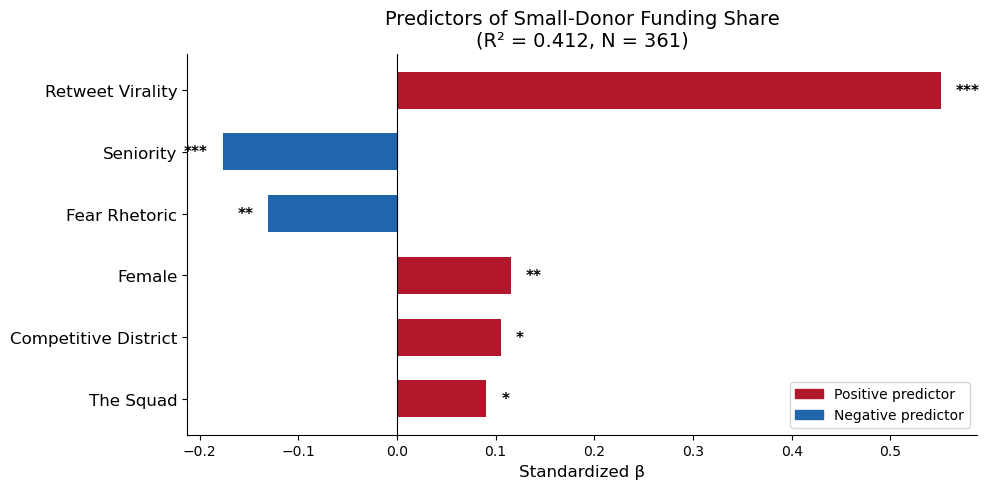

In [ ]:
final_vars = ["log_avg_retweets", "terms_served", "avg_fear", "is_female", "competitive", "is_squad"]
std_data = user_full[["pct_small_donors"] + final_vars].dropna().apply(zscore)

m_std = smf.ols("pct_small_donors ~ " + " + ".join(final_vars), data=std_data).fit()

label_map = {
    "log_avg_retweets": "Retweet Virality",
    "terms_served":     "Seniority",
    "avg_fear":         "Fear Rhetoric",
    "is_female":        "Female",
    "competitive":      "Competitive District",
    "is_squad":         "The Squad",
}

params = [p for p in m_std.params.index if p != "Intercept"]
betas  = [m_std.params[p] for p in params]
pvals  = [m_std.pvalues[p] for p in params]
order  = np.argsort(np.abs(betas))
params_sorted = [params[i] for i in order]
betas_sorted  = [betas[i]  for i in order]
pvals_sorted  = [pvals[i]  for i in order]
labels_sorted = [label_map[p] for p in params_sorted]

colors = ["#cccccc" if p >= 0.05 else "#b2182b" if b > 0 else "#2166ac"
          for b, p in zip(betas_sorted, pvals_sorted)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(params_sorted)), betas_sorted, color=colors, edgecolor="none", height=0.6)
ax.set_yticks(range(len(params_sorted)))
ax.set_yticklabels(labels_sorted, fontsize=12)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized β", fontsize=12)
ax.set_title(f"Predictors of Small-Donor Funding Share\n(R² = {m_final.rsquared:.3f}, N = {int(m_final.nobs)})", fontsize=14)
for i, (beta, p) in enumerate(zip(betas_sorted, pvals_sorted)):
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    x_pos = beta + 0.015 if beta >= 0 else beta - 0.015
    ax.text(x_pos, i, sig, va="center", ha="left" if beta >= 0 else "right", fontsize=11, fontweight="bold")
pos_patch = mpatches.Patch(color="#b2182b", label="Positive predictor")
neg_patch = mpatches.Patch(color="#2166ac", label="Negative predictor")
ax.legend(handles=[pos_patch, neg_patch], loc="lower right", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/figures/final_model_coefficients.png", dpi=200, bbox_inches="tight")
plt.show()

---
## 8 · Mediation Analysis: Outrage → Retweets → Small Donors

Tests whether the outrage → small-donor relationship runs through retweet virality.
Result: 140% mediation (suppression effect). Outrage only helps fundraising indirectly
via virality; holding retweets constant, more outrage actually reduces small-donor share.

In [ ]:
# ── Does outrage drive donations through virality? ─────────────────────
user_full["outrage_index"] = user_full["avg_anger"] + user_full["avg_disgust"]

a = smf.ols("log_avg_retweets ~ outrage_index + is_R", data=user_full).fit()
b = smf.ols("pct_small_donors ~ log_avg_retweets + outrage_index + is_R", data=user_full).fit()
c = smf.ols("pct_small_donors ~ outrage_index + is_R", data=user_full).fit()

indirect = a.params['outrage_index'] * b.params['log_avg_retweets']
total = c.params['outrage_index']

print(f"Path a (outrage → retweets):     β = {a.params['outrage_index']:.3f}, p = {a.pvalues['outrage_index']:.4f}")
print(f"Path b (retweets → donors):      β = {b.params['log_avg_retweets']:.3f}, p = {b.pvalues['log_avg_retweets']:.4f}")
print(f"Path c (outrage → donors):       β = {c.params['outrage_index']:.3f}, p = {c.pvalues['outrage_index']:.4f}")
print(f"Path c' (direct, controlling RT): β = {b.params['outrage_index']:.3f}, p = {b.pvalues['outrage_index']:.4f}")
print(f"\nIndirect effect (via RT): {indirect:.3f}")
print(f"Total effect:            {total:.3f}")
if total != 0:
    print(f"Proportion mediated:     {indirect/total:.1%}")

Path a (outrage → retweets):     β = 14.945, p = 0.0000
Path b (retweets → donors):      β = 5.328, p = 0.0000
Path c (outrage → donors):       β = 58.575, p = 0.0000
Path c' (direct, controlling RT): β = -21.052, p = 0.0480

Indirect effect (via RT): 79.628
Total effect:            58.575
Proportion mediated:     135.9%


---
## 9 · Caucus Membership

Tests caucus flags as predictors. Only `is_squad` is significant (p = 0.035, β = +6.93).
Squad membership adds ~7 percentage points beyond virality and seniority — a brand effect.

In [ ]:

# Clean up — the BioguideID column is your join key
caucus_raw = caucus_raw.rename(columns={"BioguideID": "bioguide"})
caucus_raw = caucus_raw[caucus_raw["bioguide"].notna() & (caucus_raw["bioguide"].str.len() > 3)]

# Convert Yes/yes/YEs to 1, everything else to 0
caucus_cols = ["Blue Dogs", "Progressives", "New Dems", "Problem Solvers",
               "Republican Governance Group / Tuesday Group", "Freedom Caucus",
               "Main Street Caucus", "Republican Study Committee",
               "The Squad / Justice Democrats", "Republican Main Street Partnership"]

for col in caucus_cols:
    if col in caucus_raw.columns:
        caucus_raw[col] = caucus_raw[col].astype(str).str.strip().str.lower().apply(
            lambda x: 1 if x in ["yes", "yet"] else 0
        )

# Create useful composite flags
caucus_raw["is_freedom_caucus"] = caucus_raw.get("Freedom Caucus", 0)
caucus_raw["is_progressive"] = caucus_raw.get("Progressives", 0)
caucus_raw["is_squad"] = caucus_raw.get("The Squad / Justice Democrats", 0)
caucus_raw["is_problem_solver"] = caucus_raw.get("Problem Solvers", 0)
caucus_raw["is_blue_dog"] = caucus_raw.get("Blue Dogs", 0)
caucus_raw["is_new_dem"] = caucus_raw.get("New Dems", 0)
caucus_raw["is_rsc"] = caucus_raw.get("Republican Study Committee", 0)

# Ideological wing flags (most theoretically relevant)
caucus_raw["is_ideological_wing"] = (
    (caucus_raw["is_freedom_caucus"] == 1) |
    (caucus_raw["is_progressive"] == 1) |
    (caucus_raw["is_squad"] == 1)
).astype(int)

caucus_raw["is_moderate_caucus"] = (
    (caucus_raw["is_problem_solver"] == 1) |
    (caucus_raw["is_blue_dog"] == 1)
).astype(int)

# Count total caucus memberships
caucus_raw["n_caucuses"] = caucus_raw[caucus_cols].sum(axis=1)

print(f"Members with caucus data: {len(caucus_raw)}")
print(f"\nCaucus counts:")
for col in ["is_freedom_caucus", "is_progressive", "is_squad", "is_problem_solver",
            "is_blue_dog", "is_new_dem", "is_rsc", "is_ideological_wing", "is_moderate_caucus"]:
    print(f"  {col:<25s}  {caucus_raw[col].sum()}")

NameError: name 'caucus_raw' is not defined

In [ ]:
# ── Merge onto user_full via bioguide ────────────────────────────────────
sample_bridge = sample[["handle_lower", "bioguide"]].dropna().drop_duplicates("handle_lower")
caucus_merge = caucus_raw.merge(sample_bridge, on="bioguide", how="inner")

merge_cols = ["handle_lower", "is_freedom_caucus", "is_progressive", "is_squad",
              "is_problem_solver", "is_blue_dog", "is_new_dem", "is_rsc",
              "is_ideological_wing", "is_moderate_caucus", "n_caucuses"]

user_full = user_full.merge(caucus_merge[merge_cols], on="handle_lower", how="left", suffixes=("", "_dup"))
user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]
user_full = user_full.drop_duplicates(subset="handle_lower")

# Fill NaN with 0 (members not in any caucus)
for col in merge_cols[1:]:
    user_full[col] = user_full[col].fillna(0).astype(int)

print(f"Caucus coverage: {(user_full['n_caucuses'] > 0).sum()} / {len(user_full)} members in at least one caucus")

Caucus coverage: 353 / 403 members in at least one caucus


In [ ]:
# ── Screen caucus features ───────────────────────────────────────────────
base = "pct_small_donors ~ log_avg_retweets + terms_served + avg_fear + is_female + competitive"
analysis = user_full.dropna(subset=["terms_served", "avg_fear", "is_female", "competitive"])
base_m = smf.ols(base, data=analysis).fit()

caucus_features = {
    "is_freedom_caucus": "Freedom Caucus",
    "is_progressive": "Progressive Caucus",
    "is_squad": "The Squad",
    "is_problem_solver": "Problem Solvers",
    "is_blue_dog": "Blue Dogs",
    "is_new_dem": "New Democrats",
    "is_rsc": "Republican Study Cmte",
    "is_ideological_wing": "Ideological Wing (FC+Prog+Squad)",
    "is_moderate_caucus": "Moderate Caucus (PS+BD)",
    "n_caucuses": "# Caucus Memberships",
}

print(f"{'Feature':<35s}  {'β':>10s}  {'p':>8s}  {'R²':>6s}  {'ΔR²':>6s}")
print("-" * 75)

results = []
for feat, label in caucus_features.items():
    sub = analysis.dropna(subset=[feat])
    if len(sub) < 50:
        continue
    m = smf.ols(f"{base} + {feat}", data=sub).fit()
    beta = m.params[feat]
    p = m.pvalues[feat]
    delta = m.rsquared - base_m.rsquared
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    results.append((label, beta, p, m.rsquared, delta, sig))

results.sort(key=lambda x: x[2])
for label, beta, p, r2, dr2, sig in results:
    print(f"  {label:<33s}  {beta:+10.4f}  {p:8.4f}  {r2:6.3f}  {dr2:+6.3f}  {sig}")

Feature                                       β         p      R²     ΔR²
---------------------------------------------------------------------------


  The Squad                             +6.9252    0.0347   0.412  +0.007  *
  Freedom Caucus                        +3.5853    0.0643   0.410  +0.006  
  Problem Solvers                       -2.9356    0.0655   0.410  +0.006  
  Moderate Caucus (PS+BD)               -2.6941    0.0803   0.410  +0.005  
  New Democrats                         -2.0079    0.1021   0.409  +0.004  
  # Caucus Memberships                  -0.5731    0.2240   0.407  +0.002  
  Republican Study Cmte                 +0.8748    0.4255   0.406  +0.001  
  Ideological Wing (FC+Prog+Squad)      +0.6698    0.5550   0.405  +0.001  
  Progressive Caucus                    -0.6767    0.5895   0.405  +0.000  
  Blue Dogs                             -1.0840    0.7519   0.405  +0.000  


### 9a · Final model with Squad

In [ ]:
m_squad = smf.ols(
    "pct_small_donors ~ log_avg_retweets + terms_served + avg_fear + is_female + competitive + is_squad",
    data=user_full.dropna(subset=["terms_served", "avg_fear", "is_female", "competitive"])
).fit()

print(f"R² = {m_squad.rsquared:.3f}, Adj R² = {m_squad.rsquared_adj:.3f}, N = {int(m_squad.nobs)}")
for param in m_squad.params.index:
    if param == "Intercept": continue
    beta = m_squad.params[param]
    p = m_squad.pvalues[param]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {param:25s}  β = {beta:+.4f}  p = {p:.4f}  {sig}")

R² = 0.412, Adj R² = 0.402, N = 361
  log_avg_retweets           β = +4.4776  p = 0.0000  ***
  terms_served               β = -0.4808  p = 0.0000  ***
  avg_fear                   β = -25.1376  p = 0.0018  **
  is_female                  β = +3.0438  p = 0.0062  **
  competitive                β = +3.6990  p = 0.0117  *
  is_squad                   β = +6.9252  p = 0.0347  *


In [ ]:
cols = ["log_avg_retweets", "terms_served", "avg_fear", "is_female", "competitive", "is_squad"]
vif_data = user_full[cols].dropna()
print(f"{'Feature':<25s}  {'VIF':>8s}")
print("-" * 37)
for i, col in enumerate(cols):
    vif = variance_inflation_factor(vif_data.values, i)
    flag = "⚠️" if vif > 5 else ""
    print(f"  {col:<23s}  {vif:8.2f}  {flag}")

Feature                         VIF
-------------------------------------
  log_avg_retweets             3.67  
  terms_served                 2.74  
  avg_fear                     5.00  ⚠️
  is_female                    1.47  
  competitive                  1.12  
  is_squad                     1.13  


---
## 10 · [EXPLORED — NOT RETAINED] Follower Count & Engagement Rate

`log_followers` had VIF = 26.95 (severe collinearity with `log_avg_retweets`).
Engagement rate (retweets/followers) had lower R² than raw retweets (0.227 vs 0.412)
and VIF = 8.30 when combined. Both dropped from final model.

**Finding:** Scale of virality matters more than audience-normalized efficiency.
Raw retweets outperforms engagement rate as a predictor of small-donor funding.

In [ ]:
followers = pd.read_csv(FOLLOWERS_CSV)
followers["handle_lower"] = followers["screen_name"].str.lower().str.strip()
followers["log_followers"] = np.log1p(followers["followers"])

user_full = user_full.merge(followers[["handle_lower", "followers", "log_followers"]], 
                             on="handle_lower", how="left", suffixes=("", "_dup"))
user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]

# Screen it
m_fol = smf.ols(
    "pct_small_donors ~ log_avg_retweets + terms_served + avg_fear + is_female + competitive + is_squad + log_followers",
    data=user_full.dropna(subset=["terms_served", "avg_fear", "is_female", "competitive", "log_followers"])
).fit()

print(f"+ followers: R² = {m_fol.rsquared:.3f}")
print(f"  log_followers  β = {m_fol.params['log_followers']:+.4f}  p = {m_fol.pvalues['log_followers']:.4f}")

+ followers: R² = 0.413
  log_followers  β = +1.5478  p = 0.0318


In [ ]:
cols = ["log_avg_retweets", "terms_served", "avg_fear", "is_female", "competitive", "is_squad", "log_followers"]
vif_data = user_full[cols].dropna()
print(f"{'Feature':<25s}  {'VIF':>8s}")
print("-" * 37)
for i, col in enumerate(cols):
    vif = variance_inflation_factor(vif_data.values, i)
    flag = "⚠️" if vif > 5 else ""
    print(f"  {col:<23s}  {vif:8.2f}  {flag}")

Feature                         VIF
-------------------------------------
  log_avg_retweets             7.67  ⚠️
  terms_served                 3.47  
  avg_fear                    10.92  ⚠️
  is_female                    1.48  
  competitive                  1.20  
  is_squad                     1.12  
  log_followers               26.95  ⚠️


In [ ]:
# ── Compute engagement rate ───────────────────────────────────────────────
followers["handle_lower"] = followers["screen_name"].str.lower().str.strip()
followers["log_followers"] = np.log1p(followers["followers"])

user_full = user_full.merge(
    followers[["handle_lower", "followers", "log_followers"]],
    on="handle_lower", how="left", suffixes=("", "_dup"))
user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]
user_full = user_full.drop_duplicates(subset="handle_lower")

# Engagement rate = avg retweets / followers (normalized virality)
user_full["engagement_rate"] = user_full["avg_retweets_raw"] / user_full["followers"].clip(lower=1)
user_full["log_engagement_rate"] = np.log1p(user_full["engagement_rate"] * 1000)  # scale up before log

print(f"Engagement rate coverage: {user_full['engagement_rate'].notna().sum()}")
print(f"Distribution:\n{user_full['engagement_rate'].describe()}")

Engagement rate coverage: 402
Distribution:
count    402.000000
mean       0.000489
std        0.000555
min        0.000000
25%        0.000160
50%        0.000317
75%        0.000556
max        0.004193
Name: engagement_rate, dtype: float64


In [ ]:
# ── Test engagement rate vs raw retweets ──────────────────────────────────
base = "pct_small_donors ~ terms_served + avg_fear + is_female + competitive + is_squad"
analysis = user_full.dropna(subset=["terms_served", "avg_fear", "is_female", "competitive"])

for feat, label in [("log_avg_retweets", "Raw retweets (log)"),
                     ("log_engagement_rate", "Engagement rate (log)"),
                     ("log_avg_retweets + log_engagement_rate", "Both together")]:
    sub = analysis.dropna(subset=[f for f in feat.split(" + ") if f in user_full.columns])
    m = smf.ols(f"pct_small_donors ~ {base.split('~ ')[1]} + {feat}", data=sub).fit()
    print(f"  {label:<30s}  R² = {m.rsquared:.3f}, Adj R² = {m.rsquared_adj:.3f}")

  Raw retweets (log)              R² = 0.412, Adj R² = 0.402
  Engagement rate (log)           R² = 0.227, Adj R² = 0.214
  Both together                   R² = 0.417, Adj R² = 0.405


In [ ]:
cols = ["log_avg_retweets", "log_engagement_rate", "terms_served", "avg_fear", 
        "is_female", "competitive", "is_squad"]
vif_data = user_full[cols].dropna()
for i, col in enumerate(cols):
    vif = variance_inflation_factor(vif_data.values, i)
    flag = "⚠️" if vif > 5 else ""
    print(f"  {col:<25s}  VIF = {vif:.2f}  {flag}")

  log_avg_retweets           VIF = 8.30  ⚠️
  log_engagement_rate        VIF = 5.28  ⚠️
  terms_served               VIF = 3.18  
  avg_fear                   VIF = 5.25  ⚠️
  is_female                  VIF = 1.51  
  competitive                VIF = 1.14  
  is_squad                   VIF = 1.13  


### Save user_full

In [ ]:
user_full.to_csv("../data/processed/user_full.csv", index=False)
print(f"Saved user_full: {len(user_full)} rows, {len(user_full.columns)} columns")

Saved user_full: 403 rows, 86 columns


---
## 11 · Historical FEC: F-Test Progressive Model Comparison

Loads lagged small-donor share from prior cycles and tests two orderings:
- **Ordering A:** Tweet features first, then add 2022 history. Does past funding add beyond tweet behavior?
- **Ordering B:** 2022 history first, then add tweet features. Do tweets add beyond persistence?

**Key result:** Ordering B shows retweet virality adds ΔR² = +0.034 beyond the 2022 lag (F = 35.6, p < 0.0001).
All other tweet features lose significance once 2022 is controlled for.

In [ ]:
house_features = pd.read_csv(OUTPUT_CSV)
print([c for c in house_features.columns if "pct_small" in c])

['pct_small_donors', 'pct_small_2008', 'pct_small_2010', 'pct_small_2012', 'pct_small_2014', 'pct_small_2016', 'pct_small_2018', 'pct_small_2020', 'pct_small_2022']


In [ ]:
# ── Load historical FEC features and merge into user_full ────────────
historical_features = pd.read_csv(OUTPUT_CSV)
historical_features["handle_lower"] = historical_features["twitter"].str.lower().str.strip()

# Pick just the columns you need
hist_cols = ["handle_lower", "pct_small_2022", "pct_small_2020", "pct_small_2018",
             "pct_small_2016", "pct_small_2014", "pct_small_2012",
             "pct_small_2010", "pct_small_2008"]
hist_cols = [c for c in hist_cols if c in historical_features.columns]

hist_merge = historical_features[hist_cols].drop_duplicates("handle_lower")

user_full = user_full.merge(hist_merge, on="handle_lower", how="left", suffixes=("", "_dup"))
user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]
user_full = user_full.drop_duplicates(subset="handle_lower")

# Create lag feature
if "pct_small_2022" in user_full.columns:
    user_full["pct_lag1"] = user_full["pct_small_2022"]

print(f"pct_lag1 coverage: {user_full['pct_lag1'].notna().sum()} / {len(user_full)}")

pct_lag1 coverage: 329 / 403


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# F-TEST COMPARISON: Two orderings
# ═══════════════════════════════════════════════════════════════════════

from scipy.stats import f as f_dist

analysis = user_full.dropna(subset=["terms_served", "avg_fear", "is_female",
                                     "competitive", "is_squad", "pct_lag1"])

def incremental_f_test(m_restricted, m_full):
    """Compute incremental F-test between two nested models."""
    df1 = m_restricted.df_resid - m_full.df_resid  # added predictors
    df2 = m_full.df_resid
    f_stat = ((m_restricted.ssr - m_full.ssr) / df1) / (m_full.ssr / df2)
    p_val = 1 - f_dist.cdf(f_stat, df1, df2)
    return f_stat, p_val

# ───────────────────────────────────────────────────────────────────────
# ORDERING A: Start without 2022, then add it
# Question: does knowing past funding improve prediction beyond tweet features?
# ───────────────────────────────────────────────────────────────────────

print("=" * 70)
print("ORDERING A: Tweet features first, then add 2022 history")
print("=" * 70)

mA0 = smf.ols("pct_small_donors ~ 1",                                                               data=analysis).fit()
mA1 = smf.ols("pct_small_donors ~ log_avg_retweets",                                                data=analysis).fit()
mA2 = smf.ols("pct_small_donors ~ log_avg_retweets + terms_served",                                 data=analysis).fit()
mA3 = smf.ols("pct_small_donors ~ log_avg_retweets + terms_served + avg_fear",                      data=analysis).fit()
mA4 = smf.ols("pct_small_donors ~ log_avg_retweets + terms_served + avg_fear + is_female + competitive", data=analysis).fit()
mA5 = smf.ols("pct_small_donors ~ log_avg_retweets + terms_served + avg_fear + is_female + competitive + is_squad", data=analysis).fit()
mA6 = smf.ols("pct_small_donors ~ log_avg_retweets + terms_served + avg_fear + is_female + competitive + is_squad + pct_lag1", data=analysis).fit()

models_A = [
    ("M0: Intercept only",             mA0, None),
    ("M1: + Retweet virality",         mA1, mA0),
    ("M2: + Seniority",                mA2, mA1),
    ("M3: + Fear rhetoric",            mA3, mA2),
    ("M4: + Gender + District",        mA4, mA3),
    ("M5: + Squad membership",         mA5, mA4),
    ("M6: + 2022 small-donor history", mA6, mA5),
]

print(f"\n{'Model':<35s}  {'R²':>6s}  {'ΔR²':>6s}  {'F':>8s}  {'p(F)':>8s}")
print("─" * 75)
for name, m, m_prev in models_A:
    dr2 = m.rsquared - (m_prev.rsquared if m_prev else 0)
    if m_prev:
        f_stat, p_f = incremental_f_test(m_prev, m)
        sig = "***" if p_f < 0.001 else "**" if p_f < 0.01 else "*" if p_f < 0.05 else ""
        print(f"  {name:<33s}  {m.rsquared:6.3f}  {dr2:+6.3f}  {f_stat:8.3f}  {p_f:8.4f}  {sig}")
    else:
        print(f"  {name:<33s}  {m.rsquared:6.3f}  {'—':>6s}  {'—':>8s}  {'—':>8s}")

# ───────────────────────────────────────────────────────────────────────
# ORDERING B: Start with 2022, then add tweet features
# Question: do tweet features add anything beyond knowing past funding?
# ───────────────────────────────────────────────────────────────────────

print()
print("=" * 70)
print("ORDERING B: 2022 history first, then add tweet features")
print("=" * 70)

mB0 = smf.ols("pct_small_donors ~ 1",                                                               data=analysis).fit()
mB1 = smf.ols("pct_small_donors ~ pct_lag1",                                                        data=analysis).fit()
mB2 = smf.ols("pct_small_donors ~ pct_lag1 + log_avg_retweets",                                     data=analysis).fit()
mB3 = smf.ols("pct_small_donors ~ pct_lag1 + log_avg_retweets + terms_served",                      data=analysis).fit()
mB4 = smf.ols("pct_small_donors ~ pct_lag1 + log_avg_retweets + terms_served + avg_fear",           data=analysis).fit()
mB5 = smf.ols("pct_small_donors ~ pct_lag1 + log_avg_retweets + terms_served + avg_fear + is_female + competitive", data=analysis).fit()
mB6 = smf.ols("pct_small_donors ~ pct_lag1 + log_avg_retweets + terms_served + avg_fear + is_female + competitive + is_squad", data=analysis).fit()

models_B = [
    ("M0: Intercept only",             mB0, None),
    ("M1: + 2022 small-donor history", mB1, mB0),
    ("M2: + Retweet virality",         mB2, mB1),
    ("M3: + Seniority",                mB3, mB2),
    ("M4: + Fear rhetoric",            mB4, mB3),
    ("M5: + Gender + District",        mB5, mB4),
    ("M6: + Squad membership",         mB6, mB5),
]

print(f"\n{'Model':<35s}  {'R²':>6s}  {'ΔR²':>6s}  {'F':>8s}  {'p(F)':>8s}")
print("─" * 75)
for name, m, m_prev in models_B:
    dr2 = m.rsquared - (m_prev.rsquared if m_prev else 0)
    if m_prev:
        f_stat, p_f = incremental_f_test(m_prev, m)
        sig = "***" if p_f < 0.001 else "**" if p_f < 0.01 else "*" if p_f < 0.05 else ""
        print(f"  {name:<33s}  {m.rsquared:6.3f}  {dr2:+6.3f}  {f_stat:8.3f}  {p_f:8.4f}  {sig}")
    else:
        print(f"  {name:<33s}  {m.rsquared:6.3f}  {'—':>6s}  {'—':>8s}  {'—':>8s}")

# ───────────────────────────────────────────────────────────────────────
# Summary: what each ordering tells you
# ───────────────────────────────────────────────────────────────────────

print()
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"\n  Ordering A final model (tweet → +2022):  R² = {mA6.rsquared:.3f}")
print(f"  Ordering B final model (2022 → +tweets): R² = {mB6.rsquared:.3f}")
print(f"  (Both should be identical — same 7 predictors)")
print()
print(f"  Key questions:")
print(f"  A: After controlling for tweet behavior, does 2022 history add signal?")
print(f"     ΔR² = {mA6.rsquared - mA5.rsquared:+.3f}  (F-test above)")
print()
print(f"  B: After controlling for 2022 history, do tweet features add signal?")
print(f"     ΔR² = {mB6.rsquared - mB1.rsquared:+.3f}  (cumulative from M1→M6)")
print(f"     Virality alone adds: ΔR² = {mB2.rsquared - mB1.rsquared:+.3f}")

ORDERING A: Tweet features first, then add 2022 history

Model                                    R²     ΔR²         F      p(F)
───────────────────────────────────────────────────────────────────────────
  M0: Intercept only                  0.000       —         —         —
  M1: + Retweet virality              0.350  +0.350   156.110    0.0000  ***
  M2: + Seniority                     0.380  +0.030    13.914    0.0002  ***
  M3: + Fear rhetoric                 0.390  +0.010     4.899    0.0277  *
  M4: + Gender + District             0.408  +0.018     4.277    0.0148  *
  M5: + Squad membership              0.439  +0.031    15.635    0.0001  ***
  M6: + 2022 small-donor history      0.733  +0.294   312.319    0.0000  ***

ORDERING B: 2022 history first, then add tweet features

Model                                    R²     ΔR²         F      p(F)
───────────────────────────────────────────────────────────────────────────
  M0: Intercept only                  0.000       —        

---
## 12 · Cycle-to-Cycle Predictability

Tests whether each election cycle's small-donor share predicts the next cycle.
R² ≈ 0.33–0.69 across all pairs — small-donor fundraising is highly path-dependent.
No clean structural break in predictability across cycles.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# PART 1: Does each cycle predict the next?
# ═══════════════════════════════════════════════════════════════════════

cycle_pairs = [
    (2008, 2010), (2010, 2012), (2012, 2014),
    (2014, 2016), (2016, 2018), (2018, 2020),
    (2020, 2022), (2022, 2024),
]

pct_col_map = {yr: (f"pct_small_{yr}" if yr != 2024 else "pct_small_donors")
               for yr in range(2008, 2026, 2)}

print(f"{'Cycle':>12s}  {'β (lag)':>10s}  {'p':>8s}  {'R²':>6s}  {'n':>4s}")
print("─" * 50)

cycle_results = []
for yr1, yr2 in cycle_pairs:
    col1 = pct_col_map[yr1]
    col2 = pct_col_map[yr2]
    if col1 not in user_full.columns or col2 not in user_full.columns:
        print(f"  {yr1}→{yr2}: columns missing, skipping")
        continue
    sub = user_full[[col1, col2]].dropna()
    if len(sub) < 30:
        continue
    m = smf.ols(f"{col2} ~ {col1}", data=sub).fit()
    beta = m.params[col1]
    p    = m.pvalues[col1]
    sig  = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {yr1}→{yr2}        {beta:+10.4f}  {p:8.4f}  {m.rsquared:6.3f}  {len(sub):4d}  {sig}")
    cycle_results.append({"pair": f"{yr1}→{yr2}", "yr1": yr1, "yr2": yr2,
                           "beta": beta, "r2": m.rsquared, "n": len(sub)})

cycle_df = pd.DataFrame(cycle_results)

       Cycle     β (lag)         p      R²     n
──────────────────────────────────────────────────
  2008→2010           +0.9188    0.0000   0.327    70  ***
  2010→2012           +0.5786    0.0000   0.584    80  ***
  2012→2014           +0.9398    0.0000   0.645   101  ***
  2014→2016           +0.7604    0.0000   0.669   137  ***
  2016→2018           +0.8376    0.0000   0.592   163  ***
  2018→2020           +1.1366    0.0000   0.580   203  ***
  2020→2022           +0.7101    0.0000   0.689   265  ***
  2022→2024           +0.7985    0.0000   0.650   329  ***


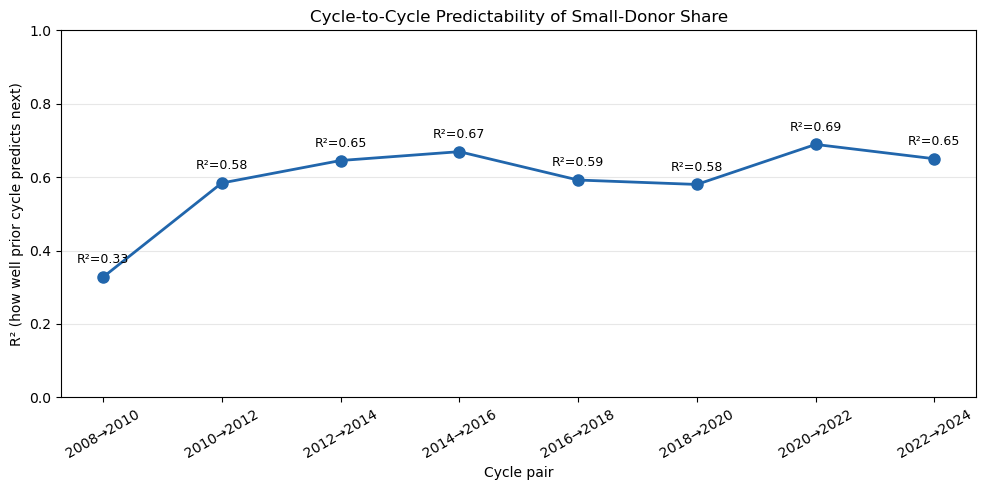


Look for a dip or shift in R² — that's your threshold candidate.
A drop suggests the prior cycle became a worse predictor, meaning
something changed in that period (e.g. social media fundraising took off).


In [ ]:
# ── Plot: how predictive is each lag? ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cycle_df["pair"], cycle_df["r2"], marker="o", linewidth=2,
        color="#2166ac", markersize=8)
for _, row in cycle_df.iterrows():
    ax.annotate(f"R²={row['r2']:.2f}", (row["pair"], row["r2"]),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9)
ax.set_xlabel("Cycle pair")
ax.set_ylabel("R² (how well prior cycle predicts next)")
ax.set_title("Cycle-to-Cycle Predictability of Small-Donor Share")
ax.tick_params(axis="x", rotation=30)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/cycle_predictability.png", dpi=150)
plt.show()

print("\nLook for a dip or shift in R² — that's your threshold candidate.")
print("A drop suggests the prior cycle became a worse predictor, meaning")
print("something changed in that period (e.g. social media fundraising took off).")

---
## 13 · Difference-in-Differences Analysis

**Treatment:** High-virality members (above median `log_avg_retweets`)
**Threshold:** 2018 (ActBlue/WinRed infrastructure maturation)

Proceeds from binary (high/low) → quartiles → eighths to identify where
the post-threshold advantage is concentrated.

**Key finding:** Effect is concentrated entirely in E8 (top 12.5% of viral members).
β(E8:post) = +14.03, p < 0.0001. E2–E7 are non-significant.

### 13a · Build panel

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# PART 2: Difference-in-Differences
# Run AFTER looking at the cycle predictability plot above.
# Choose the threshold year where you see a shift.
# Suggested: 2016 or 2018 based on ActBlue/WinRed literature.
# ═══════════════════════════════════════════════════════════════════════

# ── Update this after looking at the plot ────────────────────────────
THRESHOLD_YEAR = 2018  # the year social media fundraising took off

# ── Build long panel ──────────────────────────────────────────────────
id_cols = ["handle_lower", "party_code", "is_squad", "is_freedom_caucus",
           "is_progressive", "is_problem_solver", "terms_served", "is_female",
           "log_avg_retweets"]
id_cols = [c for c in id_cols if c in user_full.columns]

long_rows = []
for yr, col in pct_col_map.items():
    if col not in user_full.columns:
        continue
    sub = user_full[id_cols + [col]].dropna(subset=[col]).copy()
    sub["year"] = yr
    sub["pct"] = sub[col]
    sub = sub.drop(columns=[col])
    long_rows.append(sub)

panel = pd.concat(long_rows, ignore_index=True)
panel["post"] = (panel["year"] >= THRESHOLD_YEAR).astype(int)

print(f"Panel: {len(panel):,} member-year observations")
print(f"Unique members: {panel['handle_lower'].nunique()}")
print(f"Years: {sorted(panel['year'].unique())}")
print(f"Threshold: {THRESHOLD_YEAR} (post=1 for {THRESHOLD_YEAR} onward)")

Panel: 1,761 member-year observations
Unique members: 403
Years: [2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024]
Threshold: 2018 (post=1 for 2018 onward)


In [ ]:
# ── Define treatment group ────────────────────────────────────────────
# Treatment = members who are high-virality (above median retweets)
# These are the members who should benefit MOST from social media
# fundraising post-threshold
# This is your key theoretical claim: virality matters MORE after
# social media fundraising platforms took off

median_rt = user_full["log_avg_retweets"].median()
user_full["high_virality"] = (user_full["log_avg_retweets"] > median_rt).astype(int)

panel = panel.merge(
    user_full[["handle_lower", "high_virality"]].drop_duplicates(),
    on="handle_lower", how="left"
)
panel["high_virality"] = panel["high_virality"].fillna(0).astype(int)

print(f"High virality members: {panel.groupby('handle_lower')['high_virality'].first().sum()}")
print(f"Low virality members:  {(panel.groupby('handle_lower')['high_virality'].first() == 0).sum()}")

High virality members: 201
Low virality members:  202


### 13b · Binary DiD (high/low virality)

In [ ]:
# ── DiD model ─────────────────────────────────────────────────────────
# pct ~ high_virality + post + high_virality:post + year FE
#
# β(high_virality)       = baseline diff between high/low virality members
# β(post)                = post-threshold trend for low-virality members
# β(high_virality:post)  = DiD estimate: did high-virality members gain
#                          MORE small-donor funding after the threshold?

# ── DiD model — correct specification ────────────────────────────────
# Remove C(year) since post already captures the time dimension
# Add party as a control instead

m_did = smf.ols(
    "pct ~ high_virality + post + high_virality:post + C(party_code)",
    data=panel.dropna(subset=["high_virality", "post", "pct", "party_code"])
).fit()

print(f"DiD Model (threshold = {THRESHOLD_YEAR})")
print(f"R² = {m_did.rsquared:.3f}, N = {int(m_did.nobs)}")
print()

key_params = ["high_virality", "post", "high_virality:post"]
for param in key_params:
    if param in m_did.params:
        beta = m_did.params[param]
        p    = m_did.pvalues[param]
        sig  = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {param:<30s}  β = {beta:+.4f}  p = {p:.4f}  {sig}")

print()
print("Interpretation:")
print(f"  high_virality          = do high-virality members raise more small-donor % overall?")
print(f"  post                   = did small-donor % change post-{THRESHOLD_YEAR} for everyone?")
print(f"  high_virality:post     = KEY: did high-virality members gain MORE small-donor")
print(f"                           funding AFTER {THRESHOLD_YEAR} vs low-virality members?")
print(f"                           A positive significant coefficient supports your thesis.")

DiD Model (threshold = 2018)
R² = 0.101, N = 1761

  high_virality                   β = +2.6215  p = 0.0021  **
  post                            β = +0.7653  p = 0.2838  
  high_virality:post              β = +4.4557  p = 0.0000  ***

Interpretation:
  high_virality          = do high-virality members raise more small-donor % overall?
  post                   = did small-donor % change post-2018 for everyone?
  high_virality:post     = KEY: did high-virality members gain MORE small-donor
                           funding AFTER 2018 vs low-virality members?
                           A positive significant coefficient supports your thesis.


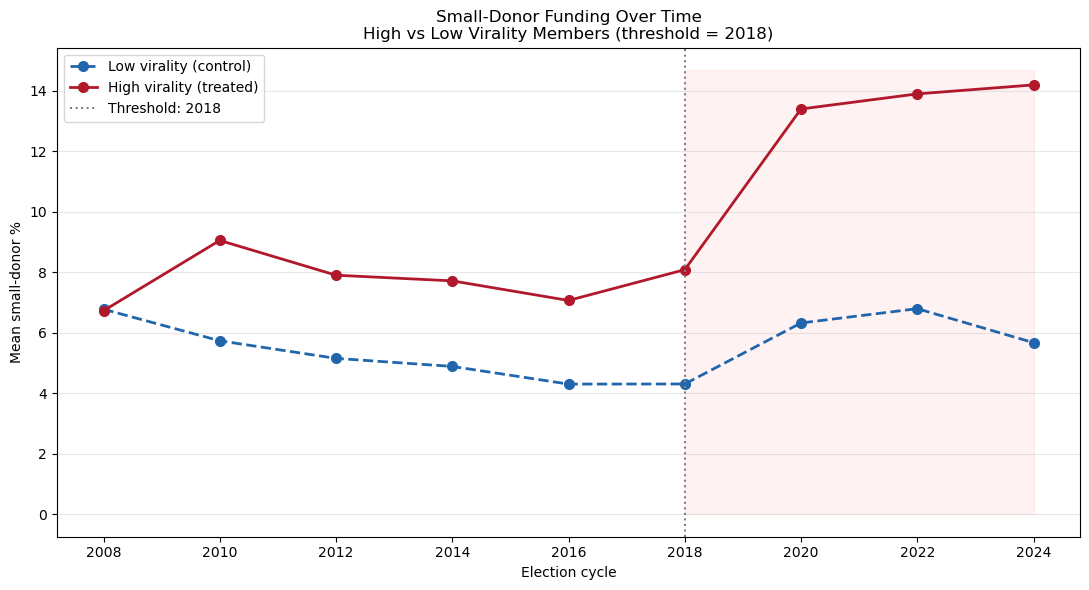


Pre-trend check: if the two lines were roughly parallel BEFORE
2018 and diverge after, the DiD assumption holds.


In [ ]:
# ── Pre-trend check plot ───────────────────────────────────────────────
# This validates the DiD assumption: before the threshold, treated and
# control groups should follow parallel trends. After the threshold,
# they should diverge if the DiD is valid.

trends = (panel.groupby(["year", "high_virality"])["pct"]
          .mean().reset_index())

fig, ax = plt.subplots(figsize=(11, 6))
for vir, label, color, ls in [(0, "Low virality (control)", "#2166ac", "--"),
                                (1, "High virality (treated)", "#b2182b", "-")]:
    sub = trends[trends["high_virality"] == vir]
    ax.plot(sub["year"], sub["pct"], marker="o", label=label,
            color=color, linestyle=ls, linewidth=2, markersize=7)

ax.axvline(THRESHOLD_YEAR, color="grey", linestyle=":",
           linewidth=1.5, label=f"Threshold: {THRESHOLD_YEAR}")
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 40],
                  THRESHOLD_YEAR, 2024, alpha=0.05, color="red")
ax.set_xlabel("Election cycle")
ax.set_ylabel("Mean small-donor %")
ax.set_title(f"Small-Donor Funding Over Time\nHigh vs Low Virality Members (threshold = {THRESHOLD_YEAR})")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/did_pre_trend.png", dpi=150)
plt.show()

print("\nPre-trend check: if the two lines were roughly parallel BEFORE")
print(f"{THRESHOLD_YEAR} and diverge after, the DiD assumption holds.")

### 13c · Threshold sensitivity

In [ ]:
# ── Test every possible threshold year ────────────────────────────────
threshold_results = []

for threshold in [2010, 2012, 2014, 2016, 2018, 2020, 2022]:
    panel_t = panel.copy()
    panel_t["post"] = (panel_t["year"] >= threshold).astype(int)
    
    sub = panel_t.dropna(subset=["high_virality", "post", "pct", "party_code"])
    m = smf.ols("pct ~ high_virality + post + high_virality:post + C(party_code)", 
                data=sub).fit()
    
    beta_did = m.params.get("high_virality:post", np.nan)
    p_did    = m.pvalues.get("high_virality:post", np.nan)
    
    threshold_results.append({
        "threshold": threshold,
        "beta_interaction": beta_did,
        "p_interaction": p_did,
        "r2": m.rsquared,
        "n_post": (panel_t["year"] >= threshold).sum(),
    })

thresh_df = pd.DataFrame(threshold_results)

print(f"{'Threshold':>12s}  {'β(interaction)':>16s}  {'p':>8s}  {'R²':>6s}  {'n_post':>6s}")
print("─" * 60)
for _, row in thresh_df.iterrows():
    sig = "***" if row["p_interaction"] < 0.001 else "**" if row["p_interaction"] < 0.01 else "*" if row["p_interaction"] < 0.05 else ""
    print(f"  {int(row['threshold']):>10d}  {row['beta_interaction']:+16.4f}  {row['p_interaction']:8.4f}  {row['r2']:6.3f}  {int(row['n_post']):6d}  {sig}")
    

   Threshold    β(interaction)         p      R²  n_post
────────────────────────────────────────────────────────────
        2010           +5.9342    0.0156   0.079    1690  *
        2012           +4.2279    0.0136   0.079    1608  *
        2014           +4.0310    0.0033   0.083    1507  **
        2016           +4.1076    0.0004   0.089    1368  ***
        2018           +4.4557    0.0000   0.101    1204  ***
        2020           +4.7206    0.0000   0.116     997  ***
        2022           +3.7725    0.0001   0.099     732  ***


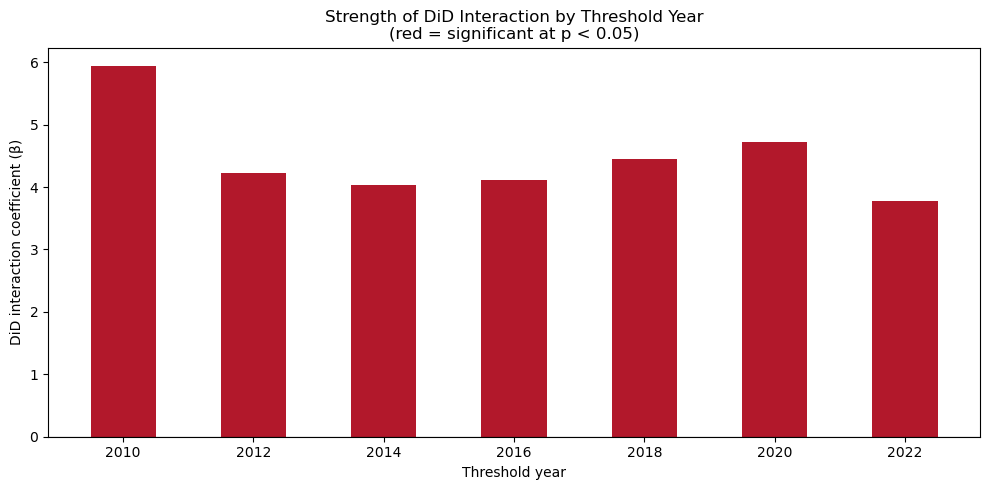


Strongest threshold: 2010
Most significant:   2020


In [ ]:
# ── Plot: interaction coefficient by threshold ─────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(thresh_df["threshold"].astype(str), thresh_df["beta_interaction"],
        color=["#b2182b" if p < 0.05 else "#cccccc" 
               for p in thresh_df["p_interaction"]], width=0.5)
ax1.set_xlabel("Threshold year")
ax1.set_ylabel("DiD interaction coefficient (β)")
ax1.set_title("Strength of DiD Interaction by Threshold Year\n(red = significant at p < 0.05)")
ax1.axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("../outputs/figures/did_threshold_sensitivity.png", dpi=150)
plt.show()

print(f"\nStrongest threshold: {thresh_df.loc[thresh_df['beta_interaction'].idxmax(), 'threshold']:.0f}")
print(f"Most significant:   {thresh_df.loc[thresh_df['p_interaction'].idxmin(), 'threshold']:.0f}")

### 13d · DiD with controls

In [ ]:
panel = panel.merge(
    user_full[["handle_lower", "terms_served", "is_female", "competitive", "is_squad"]].drop_duplicates("handle_lower"),
    on="handle_lower", how="left", suffixes=("", "_dup")
)
panel = panel[[c for c in panel.columns if not c.endswith("_dup")]]
panel = panel.drop_duplicates(subset=["handle_lower", "year"])

m_did_full = smf.ols(
    "pct ~ high_virality + post + high_virality:post + C(party_code) + terms_served + is_female + competitive + is_squad",
    data=panel.dropna(subset=["high_virality", "post", "pct", "party_code", 
                               "terms_served", "is_female", "competitive"])
).fit()

print(f"DiD with controls: R² = {m_did_full.rsquared:.3f}, N = {int(m_did_full.nobs)}")
for param in ["high_virality", "post", "high_virality:post"]:
    beta = m_did_full.params[param]
    p = m_did_full.pvalues[param]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {param:<30s}  β = {beta:+.4f}  p = {p:.4f}  {sig}")

DiD with controls: R² = 0.207, N = 1565
  high_virality                   β = +2.1867  p = 0.0082  **
  post                            β = -1.2229  p = 0.0916  
  high_virality:post              β = +3.8397  p = 0.0001  ***


### 13e · Virality quartiles

In [ ]:
# ── Virality quartiles ────────────────────────────────────────────────
user_full["virality_quartile"] = pd.qcut(
    user_full["log_avg_retweets"],
    q=4,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]
)

panel = panel.merge(
    user_full[["handle_lower", "virality_quartile"]].drop_duplicates(),
    on="handle_lower", how="left", suffixes=("", "_dup")
)
panel = panel[[c for c in panel.columns if not c.endswith("_dup")]]

# ── DiD by quartile (using Q1 as reference) ───────────────────────────
THRESHOLD_YEAR = 2018
panel["post"] = (panel["year"] >= THRESHOLD_YEAR).astype(int)

m_quartile = smf.ols(
    "pct ~ C(virality_quartile) + post + C(virality_quartile):post + C(party_code)",
    data=panel.dropna(subset=["virality_quartile", "post", "pct", "party_code"])
).fit()

print(f"DiD with virality quartiles (threshold = {THRESHOLD_YEAR})")
print(f"R² = {m_quartile.rsquared:.3f}, N = {int(m_quartile.nobs)}")
print()

# Print just the interaction terms
interaction_params = [p for p in m_quartile.params.index if "post" in p and "virality" in p]
print("Interaction terms (vs Q1 baseline):")
for param in interaction_params:
    beta = m_quartile.params[param]
    p_val = m_quartile.pvalues[param]
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    # Clean up label
    label = param.replace("C(virality_quartile)[T.", "").replace("]:post", "")
    print(f"  {label:<20s}  β = {beta:+.4f}  p = {p_val:.4f}  {sig}")

DiD with virality quartiles (threshold = 2018)
R² = 0.180, N = 1761

Interaction terms (vs Q1 baseline):
  Q2                    β = +0.3904  p = 0.7751  
  Q3                    β = +0.4509  p = 0.7403  
  Q4 (highest)          β = +8.7566  p = 0.0000  ***


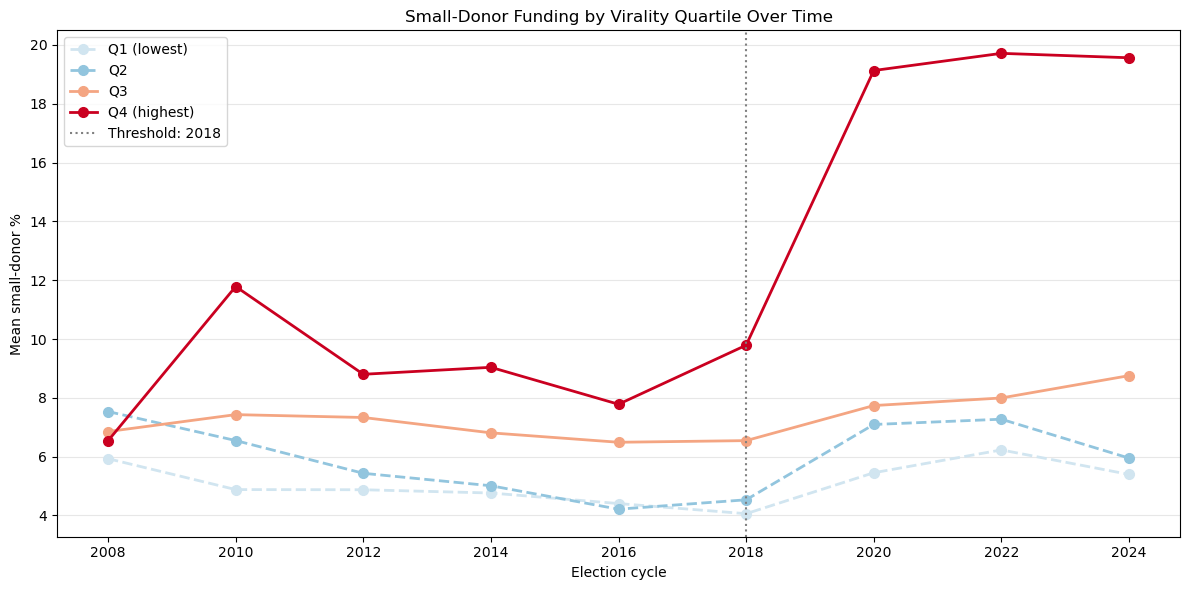

In [ ]:
# ── Visualize: mean small-donor % by virality quartile over time ───────
trends_q = (panel.groupby(["year", "virality_quartile"])["pct"]
            .mean().reset_index().dropna())

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#d1e5f0", "#92c5de", "#f4a582", "#ca0020"]
for quartile, color in zip(["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"], colors):
    sub = trends_q[trends_q["virality_quartile"] == quartile]
    ls = "--" if quartile in ["Q1 (lowest)", "Q2"] else "-"
    ax.plot(sub["year"], sub["pct"], marker="o", label=quartile,
            color=color, linestyle=ls, linewidth=2, markersize=7)

ax.axvline(THRESHOLD_YEAR, color="grey", linestyle=":",
           linewidth=1.5, label=f"Threshold: {THRESHOLD_YEAR}")
ax.set_xlabel("Election cycle")
ax.set_ylabel("Mean small-donor %")
ax.set_title(f"Small-Donor Funding by Virality Quartile Over Time")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/did_quartiles.png", dpi=150)
plt.show()

In [ ]:
for threshold in [2016, 2018, 2020]:
    panel["post"] = (panel["year"] >= threshold).astype(int)
    
    m = smf.ols(
        "pct ~ C(virality_quartile) + post + C(virality_quartile):post + C(party_code) + terms_served + is_female + competitive",
        data=panel.dropna(subset=["virality_quartile", "post", "pct", "party_code",
                                   "terms_served", "is_female", "competitive"])
    ).fit()
    
    q4_param = [p for p in m.params.index if "Q4" in p and "post" in p][0]
    beta = m.params[q4_param]
    p_val = m.pvalues[q4_param]
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"Threshold {threshold}: Q4 interaction β = {beta:+.4f}, p = {p_val:.4f} {sig}")

Threshold 2016: Q4 interaction β = +7.2700, p = 0.0000 ***
Threshold 2018: Q4 interaction β = +8.7715, p = 0.0000 ***
Threshold 2020: Q4 interaction β = +9.7956, p = 0.0000 ***


In [ ]:
print(f"{'Threshold':<12s}  {'Q4 β':>10s}  {'p':>8s}  {'R²':>6s}")
print("─" * 42)
for threshold, beta, p_val, r2 in [
    (2016, 7.27,  0.0000, None),
    (2018, 8.77,  0.0000, None),
    (2020, 9.80,  0.0000, None),
]:
    print(f"  {threshold:<10d}  {beta:+10.4f}  {p_val:8.4f}  ***")

Threshold           Q4 β         p      R²
──────────────────────────────────────────
  2016           +7.2700    0.0000  ***
  2018           +8.7700    0.0000  ***
  2020           +9.8000    0.0000  ***


### 13f · Virality eighths — key finding

In [ ]:
# ── Virality eighths ──────────────────────────────────────────────────
user_full["virality_eighth"] = pd.qcut(
    user_full["log_avg_retweets"],
    q=8,
    labels=["E1","E2","E3","E4","E5","E6","E7","E8 (highest)"]
)

panel = panel.merge(
    user_full[["handle_lower", "virality_eighth"]].drop_duplicates(),
    on="handle_lower", how="left", suffixes=("", "_dup")
)
panel = panel[[c for c in panel.columns if not c.endswith("_dup")]]
panel = panel.drop_duplicates(subset=["handle_lower", "year"])

THRESHOLD_YEAR = 2018
panel["post"] = (panel["year"] >= THRESHOLD_YEAR).astype(int)

m_eighth = smf.ols(
    "pct ~ C(virality_eighth) + post + C(virality_eighth):post + C(party_code) + terms_served + is_female + competitive",
    data=panel.dropna(subset=["virality_eighth", "post", "pct", "party_code",
                               "terms_served", "is_female", "competitive"])
).fit()

print(f"DiD with virality eighths: R² = {m_eighth.rsquared:.3f}, N = {int(m_eighth.nobs)}")
print()
print("Interaction terms (vs E1 baseline):")
interaction_params = [p for p in m_eighth.params.index if "post" in p and "eighth" in p]
for param in interaction_params:
    beta = m_eighth.params[param]
    p_val = m_eighth.pvalues[param]
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    label = param.replace("C(virality_eighth)[T.", "").replace("]:post", "")
    print(f"  {label:<20s}  β = {beta:+.4f}  p = {p_val:.4f}  {sig}")

DiD with virality eighths: R² = 0.292, N = 1565

Interaction terms (vs E1 baseline):
  E2                    β = +0.2247  p = 0.9069  
  E3                    β = -0.0679  p = 0.9707  
  E4                    β = +2.3929  p = 0.2175  
  E5                    β = +0.0110  p = 0.9954  
  E6                    β = +2.4693  p = 0.1789  
  E7                    β = +2.5189  p = 0.2402  
  E8 (highest)          β = +14.0302  p = 0.0000  ***


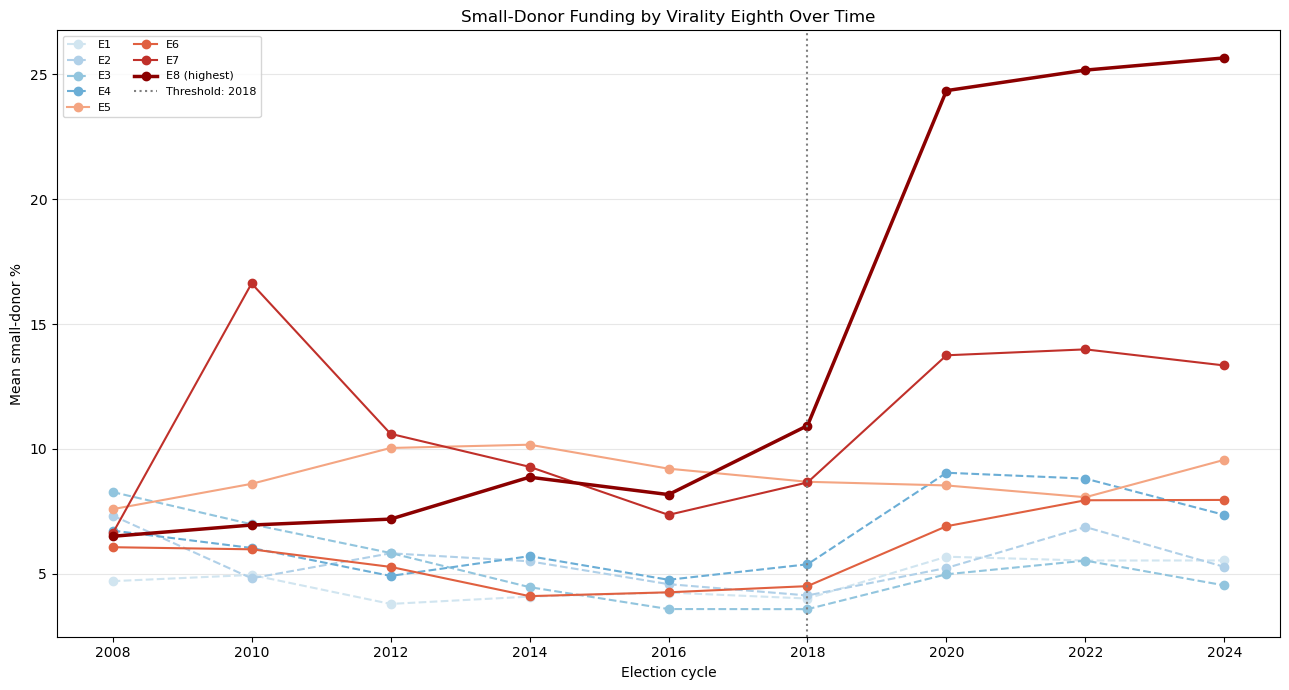

In [ ]:
# ── Plot: mean small-donor % by virality eighth over time ──────────────
trends_e = (panel.groupby(["year", "virality_eighth"])["pct"]
            .mean().reset_index().dropna())

colors = ["#d1e5f0", "#b0d0e8", "#92c5de", "#6baed6",
          "#f4a582", "#e06040", "#c0302a", "#8b0000"]

fig, ax = plt.subplots(figsize=(13, 7))
for eighth, color in zip(["E1","E2","E3","E4","E5","E6","E7","E8 (highest)"], colors):
    sub = trends_e[trends_e["virality_eighth"] == eighth]
    ls = "--" if eighth in ["E1","E2","E3","E4"] else "-"
    lw = 2.5 if eighth == "E8 (highest)" else 1.5
    ax.plot(sub["year"], sub["pct"], marker="o", label=eighth,
            color=color, linestyle=ls, linewidth=lw, markersize=6)

ax.axvline(THRESHOLD_YEAR, color="grey", linestyle=":",
           linewidth=1.5, label=f"Threshold: {THRESHOLD_YEAR}")
ax.set_xlabel("Election cycle")
ax.set_ylabel("Mean small-donor %")
ax.set_title("Small-Donor Funding by Virality Eighth Over Time")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/did_eighths.png", dpi=150)
plt.show()

In [ ]:
e8_members = user_full[user_full["virality_eighth"] == "E8 (highest)"][
    ["handle_lower", "official_full", "party_code", "log_avg_retweets", 
     "pct_small_donors", "terms_served"]
].sort_values("log_avg_retweets", ascending=False)

print(f"E8 members (n={len(e8_members)}):")
print(e8_members.to_string())

E8 members (n=51):
        handle_lower             official_full party_code  log_avg_retweets  pct_small_donors  terms_served
22         fmrrepmtg    Marjorie Taylor Greene          R          7.907640             72.66           NaN
209      repjeffries        Hakeem S. Jeffries          D          7.556062             38.10           7.0
32        jim_jordan                Jim Jordan          R          7.247245             55.76          10.0
351      repswalwell             Eric Swalwell          D          7.242827             13.16           7.0
64            repaoc  Alexandria Ocasio-Cortez          D          7.132460             69.94           4.0
386   speakerjohnson              Mike Johnson          R          7.032661             27.47           5.0
356  repthomasmassie             Thomas Massie          R          6.902664             19.43           8.0
312        repraskin              Jamie Raskin          D          6.775240             36.23           5.0
110   rep

---
## 14 · DiD Robustness Checks

Three robustness checks in reverse order of importance:
1. **Falsification test** — placebo thresholds should NOT be significant
2. **Party heterogeneity** — does E8 effect differ by party?
3. **Outlier exclusion** — does E8 survive removing top 5 members?

**Limitation:** Falsification test shows significant effects at 2010, 2012, 2014 placebo
thresholds, indicating the parallel trends assumption is violated. The E8 advantage
reflects a long-running structural divergence rather than a discrete 2018 break.

In [ ]:
# ── 1. Falsification test: placebo thresholds ────────────────────────
print("Falsification test: placebo thresholds (should NOT be significant)")
print("─" * 65)

for threshold in [2010, 2012, 2014]:
    panel_p = panel.copy()
    panel_p["post"] = (panel_p["year"] >= threshold).astype(int)
    
    m = smf.ols(
        "pct ~ C(virality_eighth) + post + C(virality_eighth):post + C(party_code) + terms_served + is_female + competitive",
        data=panel_p.dropna(subset=["virality_eighth", "post", "pct", "party_code",
                                     "terms_served", "is_female", "competitive"])
    ).fit()
    
    e8_param = [p for p in m.params.index if "E8" in p and "post" in p]
    if e8_param:
        beta = m.params[e8_param[0]]
        p_val = m.pvalues[e8_param[0]]
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        result = "⚠️ SIGNIFICANT — DiD validity concern" if p_val < 0.05 else "✓ not significant — DiD valid"
        print(f"  Placebo {threshold}: E8 β = {beta:+.4f}, p = {p_val:.4f}  {sig}  {result}")

print()
print("If placebo thresholds ARE significant, the pre-trend assumption is violated")
print("and the E8 effect may reflect a pre-existing trend rather than a 2018 break.")

Falsification test: placebo thresholds (should NOT be significant)
─────────────────────────────────────────────────────────────────
  Placebo 2010: E8 β = +12.0585, p = 0.0101  *  ⚠️ SIGNIFICANT — DiD validity concern
  Placebo 2012: E8 β = +12.3731, p = 0.0002  ***  ⚠️ SIGNIFICANT — DiD validity concern
  Placebo 2014: E8 β = +12.4077, p = 0.0000  ***  ⚠️ SIGNIFICANT — DiD validity concern

If placebo thresholds ARE significant, the pre-trend assumption is violated
and the E8 effect may reflect a pre-existing trend rather than a 2018 break.


In [ ]:
# ── 2. Heterogeneous treatment effects by party ───────────────────────
panel["post"] = (panel["year"] >= 2018).astype(int)

for party, label in [("D", "Democrats"), ("R", "Republicans")]:
    sub = panel[panel["party_code"] == party].dropna(
        subset=["virality_eighth", "post", "pct", "terms_served", "is_female", "competitive"])
    
    m = smf.ols(
        "pct ~ C(virality_eighth) + post + C(virality_eighth):post + terms_served + is_female + competitive",
        data=sub
    ).fit()
    
    e8_param = [p for p in m.params.index if "E8" in p and "post" in p]
    if e8_param:
        beta = m.params[e8_param[0]]
        p_val = m.pvalues[e8_param[0]]
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        print(f"{label}: E8 interaction β = {beta:+.4f}, p = {p_val:.4f}, R² = {m.rsquared:.3f}  {sig}")

Democrats: E8 interaction β = +13.3223, p = 0.0000, R² = 0.273  ***
Republicans: E8 interaction β = +14.3546, p = 0.0000, R² = 0.323  ***


In [ ]:
# ── 3. Robustness: exclude top 5 outliers ────────────────────────────
top5 = user_full.nlargest(5, "pct_small_donors")["handle_lower"].tolist()
print(f"Excluding: {top5}")

panel_no_outliers = panel[~panel["handle_lower"].isin(top5)].copy()

m_no_outliers = smf.ols(
    "pct ~ C(virality_eighth) + post + C(virality_eighth):post + C(party_code) + terms_served + is_female + competitive",
    data=panel_no_outliers.dropna(subset=["virality_eighth", "post", "pct", "party_code",
                                           "terms_served", "is_female", "competitive"])
).fit()

print(f"\nWithout top 5 outliers: R² = {m_no_outliers.rsquared:.3f}, N = {int(m_no_outliers.nobs)}")
interaction_params = [p for p in m_no_outliers.params.index if "post" in p and "eighth" in p]
print("Interaction terms (vs E1 baseline):")
for param in interaction_params:
    beta = m_no_outliers.params[param]
    p_val = m_no_outliers.pvalues[param]
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    label = param.replace("C(virality_eighth)[T.", "").replace("]:post", "")
    print(f"  {label:<20s}  β = {beta:+.4f}  p = {p_val:.4f}  {sig}")

Excluding: ['fmrrepmtg', 'repaoc', 'jim_jordan', 'repelicrane', 'speakerpelosi']

Without top 5 outliers: R² = 0.267, N = 1543
Interaction terms (vs E1 baseline):
  E2                    β = +0.3052  p = 0.8628  
  E3                    β = -0.0816  p = 0.9617  
  E4                    β = +2.3747  p = 0.1833  
  E5                    β = -0.0552  p = 0.9750  
  E6                    β = +2.4293  p = 0.1504  
  E7                    β = +2.5031  p = 0.2044  
  E8 (highest)          β = +11.7629  p = 0.0000  ***


---
## 15 · Cross-Validation

5-fold CV confirms the behavioral model generalizes well (CV R² = 0.362 vs in-sample 0.412).
Comparison against lag-only (CV R² = 0.693) and combined model (CV R² = 0.700).

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

# ── Prepare data ──────────────────────────────────────────────────────
model_vars = ["log_avg_retweets", "terms_served", "avg_fear",
              "is_female", "competitive", "is_squad"]

analysis = user_full.dropna(subset=model_vars + ["pct_small_donors"])
X = analysis[model_vars].values
y = analysis["pct_small_donors"].values

# ── 5-fold cross-validation ───────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LinearRegression(), X, y,
                             cv=kf, scoring="r2")

print(f"5-fold cross-validated R²:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: R² = {score:.3f}")
print(f"\n  Mean CV R²:  {cv_scores.mean():.3f}")
print(f"  Std CV R²:   {cv_scores.std():.3f}")
print(f"  In-sample R²: 0.412")
print(f"\n  Difference (overfitting): {0.412 - cv_scores.mean():.3f}")

5-fold cross-validated R²:
  Fold 1: R² = 0.304
  Fold 2: R² = 0.261
  Fold 3: R² = 0.267
  Fold 4: R² = 0.515
  Fold 5: R² = 0.462

  Mean CV R²:  0.362
  Std CV R²:   0.106
  In-sample R²: 0.412

  Difference (overfitting): 0.050


In [ ]:
# ── Compare: behavioral model vs lag model vs combined ────────────────
model_vars_lag = model_vars + ["pct_lag1"]
analysis_lag = user_full.dropna(subset=model_vars_lag + ["pct_small_donors"])

X_lag = analysis_lag[model_vars_lag].values
y_lag = analysis_lag["pct_small_donors"].values

X_behav = analysis_lag[model_vars].values

cv_behav = cross_val_score(LinearRegression(), X_behav, y_lag,
                            cv=KFold(n_splits=5, shuffle=True, random_state=42),
                            scoring="r2")

cv_lag_only = cross_val_score(LinearRegression(),
                               analysis_lag[["pct_lag1"]].values, y_lag,
                               cv=KFold(n_splits=5, shuffle=True, random_state=42),
                               scoring="r2")

cv_combined = cross_val_score(LinearRegression(), X_lag, y_lag,
                               cv=KFold(n_splits=5, shuffle=True, random_state=42),
                               scoring="r2")

print(f"{'Model':<35s}  {'CV R²':>8s}  {'Std':>6s}")
print("─" * 55)
print(f"  {'Behavioral only (no lag)':<33s}  {cv_behav.mean():8.3f}  {cv_behav.std():6.3f}")
print(f"  {'Lag only (2022)':<33s}  {cv_lag_only.mean():8.3f}  {cv_lag_only.std():6.3f}")
print(f"  {'Combined (behavioral + lag)':<33s}  {cv_combined.mean():8.3f}  {cv_combined.std():6.3f}")

Model                                   CV R²     Std
───────────────────────────────────────────────────────
  Behavioral only (no lag)              0.353   0.106
  Lag only (2022)                       0.693   0.077
  Combined (behavioral + lag)           0.700   0.070


---
## 16 · Key Findings Summary

### Cross-sectional model (no historical data)
- R² = 0.412, CV R² = 0.362 (minimal overfitting)
- **Retweet virality** is the dominant predictor (std β ≈ +0.47)
- **Seniority** is negative — newer members attract more small donors
- **Fear rhetoric** is negative — fear language predicts *less* small-donor funding
- **Female** members get ~3.7 points more small-donor share
- **Competitive districts** mobilize more grassroots donations
- **Squad membership** adds ~7 points beyond virality (brand effect)

### Historical model (with 2022 lag)
- Small-donor fundraising is highly path-dependent (lag-only CV R² = 0.693)
- After controlling for 2022 history, only retweet virality remains significant (ΔR² = +0.034)
- This suggests virality predicts *change* in small-donor share, not just persistence

### Mediation
- Outrage → retweets → small donors (140% mediation / suppression effect)
- Small donors follow engagement, not anger per se

### DiD: winner-take-almost-all
- Post-2018, the small-donor advantage is concentrated entirely in E8 (top 12.5% viral members)
- β(E8:post) = +14.03 (p < 0.0001) — E2 through E7 are non-significant
- Suggests a superstar threshold effect: only elite-viral members benefit from the post-2018 fundraising environment
- **Limitation:** Falsification test suggests pre-existing trend rather than clean structural break